# NFXP — Original Dynamic Demand Model

**Oliver Ovdal Eiberg Jørgensen & Solveig Røndal-Liniger** — Dynamic Programming, Spring 2026

---

## Model

The consumer chooses each period $t$: $y_{it} \in \{0, 1, \ldots, J\}$ — either no purchase ($y=0$) or brand $j \in \{1,\ldots,J\}$.

**State variable:** $x_{it} = (\ell_{it},\, d_{it},\, e_t)$ where
- $\ell_{it}$: last-purchased brand
- $d_{it}$: time since last purchase
- $e_t$: promotion status (exogenous Markov chain)

**Utility (equation 1):**
$$
U_{it} = \begin{cases}
  \alpha(\ell_{it}) - \beta^{\rm dep}(\ell_{it})\cdot d_{it} & \text{if } y_{it}=0 \\
  \alpha(j) - \gamma\cdot p_{it}(j) - \beta^{\rm sc}(\ell_{it},\, j) & \text{if } y_{it}=j
\end{cases}
$$

- $\beta^{\rm dep}[\ell] \times d$: inventory depreciation linear in duration, rate is brand-specific
- $\gamma \cdot p_{it}(j)$: disutility from expenditure
- $\beta^{\rm sc}(\ell, j)$: brand switching cost

**Transition rule:**
$$
(\ell_{i,t+1},\, d_{i,t+1}) = \begin{cases}
  (\ell_{it},\, d_{it}+1) & \text{if } y_{it}=0 \\
  (j,\, 1) & \text{if } y_{it}=j
\end{cases}
$$

**Estimator:** NFXP (Rust 1987) — Nelder-Mead outer loop, VFI inner loop.

## 1. Import

In [109]:
# Standard library and scientific computing imports
import time
import math
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# 1. Simulation

## 2. Primitives and True Parameters

In [110]:
# ── Model dimensions ──────────────────────────────────────────────────────────
J     = 2       # number of brands
T     = 52      # periods per consumer
N     = 2_000   # consumers per panel
D_MAX = 20      # duration cap: d_idx ∈ {0,...,D_MAX}, paper-d ∈ {1,...,D_MAX+1}
DELTA = 0.95    # discount factor

# ── Price levels ──────────────────────────────────────────────────────────────
BASE_PRICES   = np.array([11.95, 24.95])   # regular unit prices
PROMO_DISC    = np.array([1.95,  15.67])   # promotion discount
PROMO_ENTRY   = 0.18                       # P(promotion starts)
PROMO_PERSIST = 0.0                        # P(promotion persists)

# ── True structural parameters (DGP) ─────────────────────────────────────────
#
#   u(0) = α(ℓ)  − β^dep[ℓ] · d
#   u(j) = α(j)  − γ · p(j) − β^sc(ℓ, j)
#
ALPHA_TRUE    = np.array([0.0,  0.50])           # α(1)=0 is the normalization
GAMMA_TRUE    = 0.05                             # marginal expenditure disutility
BETA_SC_TRUE  = np.array([[0.00, 0.45],          # β^sc[k,j]: switching cost k→j
                           [0.35, 0.00]])
BETA_DEP_TRUE = np.array([0.250, 0.300])         # β^dep[ℓ]: brand-specific depreciation rate

# ── Monte Carlo ───────────────────────────────────────────────────────────────
MC_REPS = 10
MC_SEED = 2024
BURN_IN = 104                                  # periods discarded before recording panel
USE_COMMON_PROMOTIONS = True                   # one weekly market promotion path for all consumers
N_STARTS = 5                                   # multi-starts for the pilot estimate
MC_N_STARTS = 3                                # multi-starts per Monte Carlo replication
START_SCALE = np.array([0.30, 0.02, 0.30, 0.30, 0.08, 0.08])

# ── Choice indexing ───────────────────────────────────────────────────────────
# choice c = 0   → no purchase
# choice c = j   → buy brand j ∈ {1,...,J}
N_CHOICES = J + 1   # 3 choices: {0, 1, 2}

# ── Parameter vector ──────────────────────────────────────────────────────────
PARAM_NAMES = ["alpha_2", "gamma", "beta_sc_12", "beta_sc_21",
               "beta_dep_1", "beta_dep_2"]

THETA_TRUE = np.array([
    ALPHA_TRUE[1],
    GAMMA_TRUE,
    BETA_SC_TRUE[0, 1],
    BETA_SC_TRUE[1, 0],
    BETA_DEP_TRUE[0],
    BETA_DEP_TRUE[1],
])
DEFAULT_THETA0 = np.array([0.25, 0.04, 0.25, 0.25, 0.20, 0.20])

print("True parameters:")
for n, v in zip(PARAM_NAMES, THETA_TRUE):
    print(f"  {n:<14} = {v}")
print(f"\nN_CHOICES={N_CHOICES}  |  BASE_PRICES={BASE_PRICES}  |  D_MAX={D_MAX}")

True parameters:
  alpha_2        = 0.5
  gamma          = 0.05
  beta_sc_12     = 0.45
  beta_sc_21     = 0.35
  beta_dep_1     = 0.25
  beta_dep_2     = 0.3

N_CHOICES=3  |  BASE_PRICES=[11.95 24.95]  |  D_MAX=20


## 3. Price Process — Hi-Lo (Assumption 2.1)

Promotion status $e_t \in \{0,1\}^J$ is a binary vector. With $J=2$ there are $2^2=4$ possible states. Brand promotions follow independent two-state Markov chains, and the joint transition probability is the product of the marginal probabilities.

In [111]:
# Enumerate all 2^J joint promotion states as binary vectors
promo_states = np.array(
    [[(s >> j) & 1 for j in range(J)] for s in range(2 ** J)], dtype=int
)
N_PROMO = len(promo_states)


def make_promo_transition() -> np.ndarray:
    # Build joint transition matrix as product of independent brand Markov chains
    trans = np.empty((N_PROMO, N_PROMO))
    for s, curr in enumerate(promo_states):
        prob_on = np.where(curr == 1, PROMO_PERSIST, PROMO_ENTRY)
        for sp, nxt in enumerate(promo_states):
            trans[s, sp] = np.prod(np.where(nxt == 1, prob_on, 1.0 - prob_on))
    return trans


PROMO_TRANS = make_promo_transition()
PRICE_BY_PROMO = BASE_PRICES - PROMO_DISC * promo_states


def stationary_distribution(trans: np.ndarray) -> np.ndarray:
    """Stationary distribution of a finite Markov transition matrix."""
    eigvals, eigvecs = np.linalg.eig(trans.T)
    idx = np.argmin(np.abs(eigvals - 1.0))
    stat = np.real(eigvecs[:, idx])
    stat = stat / stat.sum()
    if np.any(stat < 0):
        stat = np.abs(stat)
        stat = stat / stat.sum()
    return stat


PROMO_STATIONARY = stationary_distribution(PROMO_TRANS)


def draw_common_promo_path(n_periods: int, rng, initial_state: int = None) -> np.ndarray:
    """Draw one market-wide promotion path shared by all consumers."""
    path = np.empty(n_periods, dtype=int)
    e_idx = int(initial_state) if initial_state is not None else int(
        rng.choice(N_PROMO, p=PROMO_STATIONARY)
    )
    for t in range(n_periods):
        path[t] = e_idx
        e_idx = int(rng.choice(N_PROMO, p=PROMO_TRANS[e_idx]))
    return path

print("Unit prices by promotion state:")
for s, e in enumerate(promo_states):
    p = PRICE_BY_PROMO[s]
    print(f"  State {s}: e={tuple(e)}  p={p}")

Unit prices by promotion state:
  State 0: e=(np.int64(0), np.int64(0))  p=[11.95 24.95]
  State 1: e=(np.int64(1), np.int64(0))  p=[10.   24.95]
  State 2: e=(np.int64(0), np.int64(1))  p=[11.95  9.28]
  State 3: e=(np.int64(1), np.int64(1))  p=[10.    9.28]


## 4. Utility Function (equation 1)

$$
U_{it} = \begin{cases}
  \alpha(\ell_{it}) - \beta^{\rm dep}[\ell_{it}] \cdot d_{it} & \text{if } y_{it}=0 \\
  \alpha(j) - \gamma\cdot p_{it}(j) - \beta^{\rm sc}(\ell_{it},\, j) & \text{if } y_{it}=j
\end{cases}
$$

- $\gamma \cdot p_{it}(j)$: disutility from expenditure (linear in price)
- $\beta^{\rm dep}[\ell] \times d$: inventory depreciation linear in duration, rate is brand-specific
- $\beta^{\rm sc}(\ell, j)$: brand switching cost

In [112]:
def flow_util(choice, last_brand, duration, e_idx,
              alpha, gamma, beta_sc, beta_dep) -> float:
    """
    Deterministic period utility.

    choice    : 0 = no purchase; j ∈ {1,...,J} → buy brand j
    last_brand: ℓ ∈ {1,...,J}
    duration  : paper-d = d_idx + 1  ∈ {1,...,D_MAX+1}
    beta_dep  : (J,) array — brand-specific depreciation rate
    """
    l      = last_brand - 1
    prices = BASE_PRICES - PROMO_DISC * promo_states[e_idx]

    if choice == 0:
        # No purchase: inventory depreciates at brand-specific rate
        return alpha[l] - beta_dep[l] * duration

    j = choice - 1   # brand index (0-indexed)
    return alpha[j] - gamma * prices[j] - beta_sc[l, j]

## 5. Inner Loop: Value Function Iteration (VFI)

**State space:** $(\ell, d, e)$, $J \times (D_{\max}+1) \times N_e = 2 \times 26 \times 4 = 208$ states for the baseline calibration.

$V$ has shape `(J, D_MAX+1, N_PROMO)`.

Transition rules in VFI:
- No purchase: $(\ell, d_{\rm idx}) \to (\ell, \min(d_{\rm idx}+1, D_{\rm MAX}))$
- Purchase $j$: $(\ell, d_{\rm idx}) \to (j, 0)$ (paper-$d=1$)

In [113]:
def solve_vfi(alpha, gamma, beta_sc, beta_dep,
              tol: float = 1e-10, max_iter: int = 2_000) -> np.ndarray:
    """
    VFI for the original model (brand-specific β^dep).

    V shape: (J, D_MAX+1, N_PROMO).
    d_idx ∈ {0,...,D_MAX} corresponds to paper-d = d_idx + 1.
    """
    duration_idx = np.arange(D_MAX + 1)
    duration = duration_idx + 1.0
    next_duration = np.minimum(duration_idx + 1, D_MAX)

    no_purchase_util = alpha[:, None] - beta_dep[:, None] * duration[None, :]
    Q = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))
    V = np.zeros((J, D_MAX + 1, N_PROMO))

    for _ in range(max_iter):
        # Expected continuation value (integrate over promotion process)
        EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T
              ).reshape(J, D_MAX + 1, N_PROMO)

        # No purchase: state → (ℓ, min(d_idx+1, D_MAX), e')
        Q[..., 0] = no_purchase_util[:, :, None] + DELTA * EV[:, next_duration, :]

        # Purchase brand j: state → (j, d_idx=0, e')  [paper d=1]
        for j_idx in range(J):
            Q[..., j_idx + 1] = (
                alpha[j_idx]
                - gamma * PRICE_BY_PROMO[:, j_idx][None, None, :]
                - beta_sc[:, j_idx][:, None, None]
                + DELTA * EV[j_idx, 0, :][None, None, :]
            )

        # Log-sum-exp for the Emax (Gumbel extreme value assumption)
        q_max = Q.max(axis=3)
        V_new = q_max + np.log(np.exp(Q - q_max[..., None]).sum(axis=3))

        if np.max(np.abs(V_new - V)) < tol:
            return V_new
        V = V_new

    return V

## 6. Conditional Choice Probabilities (CCPs)

$$P(j \mid s;\theta) = \frac{\exp(Q_j)}{\sum_{k}\exp(Q_k)}, \quad Q_j = u(j, s) + \delta\cdot EV(\text{next state})$$

`P` shape: `(J, D_MAX+1, N_PROMO, N_CHOICES)`.

In [114]:
def compute_ccps(V, alpha, gamma, beta_sc, beta_dep) -> np.ndarray:
    """
    Compute CCPs from solved value function V.
    P shape: (J, D_MAX+1, N_PROMO, N_CHOICES).
    """
    duration_idx = np.arange(D_MAX + 1)
    duration = duration_idx + 1.0
    next_duration = np.minimum(duration_idx + 1, D_MAX)

    # Expected continuation value integrated over next promotion state
    EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T
          ).reshape(J, D_MAX + 1, N_PROMO)

    Q = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))
    no_purchase_util = alpha[:, None] - beta_dep[:, None] * duration[None, :]
    Q[..., 0] = no_purchase_util[:, :, None] + DELTA * EV[:, next_duration, :]

    for j_idx in range(J):
        Q[..., j_idx + 1] = (
            alpha[j_idx]
            - gamma * PRICE_BY_PROMO[:, j_idx][None, None, :]
            - beta_sc[:, j_idx][:, None, None]
            + DELTA * EV[j_idx, 0, :][None, None, :]
        )

    # Softmax to get choice probabilities
    weights = np.exp(Q - Q.max(axis=3, keepdims=True))
    return weights / weights.sum(axis=3, keepdims=True)

## 7. Data Simulation

`simulate_panel` simulates a consumer panel from the model's CCPs and returns:
- `Y` ∈ {0,...,J}: brand choice (0 = no purchase)
- `L`: last-purchased brand (state variable)
- `D`: duration since last purchase, d_idx ∈ {0,...,D_MAX}
- `E_IDX`: promotion status

The baseline DGP uses a burn-in period for initial endogenous states and one common weekly promotion path faced by all consumers.

In [115]:
def _sample_rows(rng, row_probs: np.ndarray) -> np.ndarray:
    """Vectorized categorical draw: one observation per row of row_probs."""
    u = rng.random(len(row_probs))
    cumsum = np.cumsum(row_probs, axis=1)
    return (u[:, None] > cumsum).sum(axis=1)


def simulate_panel(P_true: np.ndarray,
                   n_consumers: int = N, n_periods: int = T,
                   seed=None,
                   common_promotions: bool = USE_COMMON_PROMOTIONS,
                   burn_in: int = BURN_IN,
                   promo_path: np.ndarray = None,
                   return_promo_path: bool = False) -> dict:
    """
    Simulate consumer panel from CCPs.
    P_true shape: (J, D_MAX+1, N_PROMO, N_CHOICES).

    Returns dict: Y, L, D, E_IDX — all (n_consumers, n_periods).

    If common_promotions=True, all consumers face the same weekly market
    promotion state. This is closer to scanner data than drawing an
    independent promotion path for each consumer.
    """
    rng = np.random.default_rng(seed)
    total_periods = burn_in + n_periods

    # Pre-allocate arrays for the full panel
    Y     = np.zeros((n_consumers, n_periods), dtype=int)
    L     = np.zeros((n_consumers, n_periods), dtype=int)
    D     = np.zeros((n_consumers, n_periods), dtype=int)
    E_IDX = np.zeros((n_consumers, n_periods), dtype=int)

    # Initial endogenous states. Burn-in makes these arbitrary starts wash out.
    ell = rng.integers(1, J + 1, size=n_consumers)
    dur = np.zeros(n_consumers, dtype=int)

    if common_promotions:
        if promo_path is None:
            promo_path = draw_common_promo_path(total_periods, rng)
        else:
            promo_path = np.asarray(promo_path, dtype=int)
            if len(promo_path) < total_periods:
                raise ValueError("promo_path must cover burn_in + n_periods")
    else:
        e_idx = rng.choice(N_PROMO, size=n_consumers, p=PROMO_STATIONARY)

    for tau in range(total_periods):
        if common_promotions:
            e_lookup = np.full(n_consumers, promo_path[tau], dtype=int)
        else:
            e_lookup = e_idx

        if tau >= burn_in:
            t = tau - burn_in
            # Record current state after the burn-in period
            L[:, t]     = ell
            D[:, t]     = dur
            E_IDX[:, t] = e_lookup

        # CCP lookup: state (ℓ-1, min(d,D_MAX), e)
        probs = P_true[ell - 1, np.minimum(dur, D_MAX), e_lookup, :]
        y = _sample_rows(rng, probs)
        if tau >= burn_in:
            Y[:, t] = y

        # Update state variables (transition rule)
        bought = y > 0
        ell    = np.where(bought, y, ell)                      # new brand if purchased
        dur    = np.where(bought, 0, np.minimum(dur + 1, D_MAX))
        if not common_promotions:
            e_idx = _sample_rows(rng, PROMO_TRANS[e_idx])

    out = {"Y": Y, "L": L, "D": D, "E_IDX": E_IDX}
    if return_promo_path and common_promotions:
        out["PROMO_PATH"] = promo_path[burn_in:burn_in + n_periods]
    return out


def simulate_heterogeneous_panel(alpha2_values=None,
                                 type_shares=None,
                                 n_consumers: int = N,
                                 n_periods: int = T,
                                 seed=None,
                                 common_promotions: bool = USE_COMMON_PROMOTIONS,
                                 burn_in: int = BURN_IN) -> dict:
    """Stress-test DGP with unobserved heterogeneity in alpha_2."""
    rng = np.random.default_rng(seed)
    if alpha2_values is None:
        alpha2_values = np.array([THETA_TRUE[0] - 0.30, THETA_TRUE[0] + 0.30])
    else:
        alpha2_values = np.asarray(alpha2_values, dtype=float)

    if type_shares is None:
        type_shares = np.ones(len(alpha2_values)) / len(alpha2_values)
    else:
        type_shares = np.asarray(type_shares, dtype=float)
        type_shares = type_shares / type_shares.sum()

    type_ids = rng.choice(len(alpha2_values), size=n_consumers, p=type_shares)
    total_periods = burn_in + n_periods
    promo_path = draw_common_promo_path(total_periods, rng) if common_promotions else None

    out = {
        "Y": np.zeros((n_consumers, n_periods), dtype=int),
        "L": np.zeros((n_consumers, n_periods), dtype=int),
        "D": np.zeros((n_consumers, n_periods), dtype=int),
        "E_IDX": np.zeros((n_consumers, n_periods), dtype=int),
        "TYPE": type_ids,
    }

    for type_id, alpha2 in enumerate(alpha2_values):
        idx = np.where(type_ids == type_id)[0]
        if len(idx) == 0:
            continue
        theta_type = THETA_TRUE.copy()
        theta_type[0] = alpha2
        a_type, g_type, sc_type, dep_type = unpack(theta_type)
        V_type = solve_vfi(a_type, g_type, sc_type, dep_type)
        P_type = compute_ccps(V_type, a_type, g_type, sc_type, dep_type)
        data_type = simulate_panel(
            P_type,
            n_consumers=len(idx),
            n_periods=n_periods,
            seed=int(rng.integers(0, 1_000_000)),
            common_promotions=common_promotions,
            burn_in=burn_in,
            promo_path=promo_path,
        )
        for key in ["Y", "L", "D", "E_IDX"]:
            out[key][idx, :] = data_type[key]

    if common_promotions:
        out["PROMO_PATH"] = promo_path[burn_in:burn_in + n_periods]
    return out

## 8. Log-Likelihood and NFXP

**Log-likelihood:**
$$\ell(\theta) = \sum_{i,t} \log P(y_{it} \mid \ell_{it}, d_{it}, e_{it}; \theta)$$

**NFXP (Rust 1987):** outer Nelder-Mead minimizes $-\ell(\theta)$; inner VFI solves the Bellman equation at each candidate $\theta$.

**Parameter vector:**
$$\theta = [\alpha_2,\; \gamma,\; \beta^{sc}_{12},\; \beta^{sc}_{21},\; \beta^{dep}_1,\; \beta^{dep}_2]$$

In [116]:
def log_likelihood(data: dict, P: np.ndarray) -> float:
    """Summed log-likelihood over all (i,t) observations."""
    Y, L, D, E = data["Y"], data["L"], data["D"], data["E_IDX"]
    probs = P[L - 1, D, E, Y]
    return float(np.sum(np.log(np.maximum(probs, 1e-300))))


def state_choice_counts(data: dict) -> np.ndarray:
    """Aggregate simulated panel observations by state and realized choice."""
    counts = np.zeros((J, D_MAX + 1, N_PROMO, N_CHOICES), dtype=float)
    np.add.at(
        counts,
        (
            data["L"].ravel() - 1,
            data["D"].ravel(),
            data["E_IDX"].ravel(),
            data["Y"].ravel(),
        ),
        1.0,
    )
    return counts


def log_likelihood_counts(counts: np.ndarray, P: np.ndarray) -> float:
    """Summed log-likelihood using state-choice counts."""
    return float(np.sum(counts * np.log(np.maximum(P, 1e-300))))


def unpack(theta: np.ndarray):
    """Unpack theta = [alpha_2, gamma, beta_sc_12, beta_sc_21, beta_dep_1, beta_dep_2]."""
    alpha    = np.array([0.0, theta[0]])
    gamma    = float(theta[1])
    beta_sc  = np.array([[0.0, theta[2]], [theta[3], 0.0]])
    beta_dep = np.array([theta[4], theta[5]])   # (J,) brand-specific rates
    return alpha, gamma, beta_sc, beta_dep


def invalid_theta(theta: np.ndarray) -> bool:
    """Economic sign restrictions used as a smooth optimizer guard."""
    theta = np.asarray(theta)
    return (theta[1] <= 0.0) or np.any(theta[2:] < 0.0)


def nfxp_objective(theta: np.ndarray, data_or_counts) -> float:
    # Solve VFI, compute CCPs, and return negative log-likelihood.
    # Passing pre-aggregated counts is algebraically equivalent and faster.
    if invalid_theta(theta):
        return 1e12 + 1e8 * float(np.sum(np.minimum(theta[1:], 0.0) ** 2))
    counts = state_choice_counts(data_or_counts) if isinstance(data_or_counts, dict) else data_or_counts
    alpha, gamma, beta_sc, beta_dep = unpack(theta)
    V = solve_vfi(alpha, gamma, beta_sc, beta_dep)
    P = compute_ccps(V, alpha, gamma, beta_sc, beta_dep)
    return -log_likelihood_counts(counts, P)


def estimate_nfxp(data_or_counts, theta0: np.ndarray = None, verbose: bool = False):
    """Estimate the model with NFXP (Nelder-Mead)."""
    if theta0 is None:
        theta0 = DEFAULT_THETA0.copy()
    counts = state_choice_counts(data_or_counts) if isinstance(data_or_counts, dict) else data_or_counts
    return minimize(
        fun=nfxp_objective,
        x0=theta0,
        args=(counts,),
        method="Nelder-Mead",
        options={"maxiter": 10_000, "xatol": 1e-5, "fatol": 1e-5,
                 "disp": verbose, "adaptive": True},
    )


def make_starting_values(theta_center: np.ndarray = None,
                         n_starts: int = N_STARTS,
                         seed=None) -> list[np.ndarray]:
    """Create dispersed but economically admissible starting values."""
    rng = np.random.default_rng(seed)
    center = DEFAULT_THETA0.copy() if theta_center is None else np.asarray(theta_center, dtype=float)
    starts = [center.copy()]
    for _ in range(max(n_starts - 1, 0)):
        draw = center + rng.normal(0.0, START_SCALE, size=len(center))
        draw[1:] = np.maximum(draw[1:], 1e-4)
        starts.append(draw)
    return starts


def estimate_nfxp_multistart(data_or_counts,
                             theta_center: np.ndarray = None,
                             n_starts: int = N_STARTS,
                             seed=None,
                             verbose: bool = False):
    """Run NFXP from several starts and keep the lowest objective value."""
    counts = state_choice_counts(data_or_counts) if isinstance(data_or_counts, dict) else data_or_counts
    results = []
    for start_id, theta0 in enumerate(make_starting_values(theta_center, n_starts, seed), start=1):
        res = estimate_nfxp(counts, theta0=theta0, verbose=verbose)
        res.start_id = start_id
        res.theta0 = theta0
        results.append(res)

    successful = [r for r in results if r.success]
    candidates = successful if successful else results
    best = min(candidates, key=lambda r: r.fun)
    return best, results


def likelihood_profile(data_or_counts,
                       center_theta: np.ndarray,
                       param_idx: int,
                       grid: np.ndarray) -> pd.DataFrame:
    """One-dimensional likelihood profile holding other parameters fixed."""
    counts = state_choice_counts(data_or_counts) if isinstance(data_or_counts, dict) else data_or_counts
    base_nll = nfxp_objective(center_theta, counts)
    rows = []
    for value in grid:
        theta = center_theta.copy()
        theta[param_idx] = value
        nll = nfxp_objective(theta, counts)
        rows.append({
            "param": PARAM_NAMES[param_idx],
            "value": value,
            "delta_nll": nll - base_nll,
        })
    return pd.DataFrame(rows)


def profile_all_parameters(data_or_counts,
                           center_theta: np.ndarray,
                           rel_width: float = 0.40,
                           n_grid: int = 9) -> pd.DataFrame:
    """Likelihood profiles around a reference estimate for all parameters."""
    frames = []
    for idx, value in enumerate(center_theta):
        width = rel_width * max(abs(value), 0.05)
        lo = value - width if idx == 0 else max(1e-4, value - width)
        hi = value + width
        grid = np.linspace(lo, hi, n_grid)
        frames.append(likelihood_profile(data_or_counts, center_theta, idx, grid))
    return pd.concat(frames, ignore_index=True)

## 9. Pilot — Single Panel

Verify that VFI converges, the simulation looks reasonable, and that NFXP recovers the true parameters from a single panel.

In [117]:
print("Step 1: Solving DP at true parameters...")
a0, g0, sc0, dep0 = unpack(THETA_TRUE)
V_true = solve_vfi(a0, g0, sc0, dep0)
P_true = compute_ccps(V_true, a0, g0, sc0, dep0)
print("  VFI converged.")

print(f"\nStep 2: Simulating panel (N={N}, T={T}, burn-in={BURN_IN})...")
data_pilot = simulate_panel(P_true, seed=42, return_promo_path=True)
Y = data_pilot["Y"]
print(f"  No purchase: {(Y == 0).mean():.1%}")
for j in range(1, J + 1):
    print(f"  Brand {j}:     {(Y == j).mean():.1%}")

promo_counts = np.bincount(data_pilot["E_IDX"].ravel(), minlength=N_PROMO) / data_pilot["E_IDX"].size
print(f"  Promotion-state shares: {np.round(promo_counts, 3)}")

print("\nStep 3: Estimating with NFXP multi-start...")
t0 = time.perf_counter()
res_pilot, pilot_starts = estimate_nfxp_multistart(
    data_pilot, theta_center=DEFAULT_THETA0, n_starts=N_STARTS, seed=4242
)
t1 = time.perf_counter() - t0
print(
    f"  Time: {t1:.1f}s  |  Best converged: {res_pilot.success}  "
    f"|  Best start: {res_pilot.start_id}/{N_STARTS}  |  Iterations: {res_pilot.nit}"
)
print(f"  Successful starts: {sum(r.success for r in pilot_starts)}/{len(pilot_starts)}")

print("\n" + "─" * 55)
df_pilot = pd.DataFrame({
    "Parameter": PARAM_NAMES,
    "True":      THETA_TRUE,
    "NFXP":      res_pilot.x,
    "Bias":      res_pilot.x - THETA_TRUE,
})
print(df_pilot.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))

profiles_pilot = profile_all_parameters(data_pilot, res_pilot.x, rel_width=0.30, n_grid=7)
profile_width = profiles_pilot.groupby("param")["delta_nll"].max().reset_index(name="max_delta_nll")
print("\nLikelihood profile width around the pilot estimate:")
print(profile_width.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

Step 1: Solving DP at true parameters...
  VFI converged.

Step 2: Simulating panel (N=2000, T=52, burn-in=104)...
  No purchase: 43.1%
  Brand 1:     23.1%
  Brand 2:     33.8%
  Promotion-state shares: [0.673 0.154 0.135 0.038]

Step 3: Estimating with NFXP multi-start...
  Time: 33.0s  |  Best converged: True  |  Best start: 3/5  |  Iterations: 339
  Successful starts: 5/5

───────────────────────────────────────────────────────
 Parameter    True    NFXP    Bias
   alpha_2 +0.5000 +0.5102 +0.0102
     gamma +0.0500 +0.0513 +0.0013
beta_sc_12 +0.4500 +0.5775 +0.1275
beta_sc_21 +0.3500 +0.2299 -0.1201
beta_dep_1 +0.2500 +0.2654 +0.0154
beta_dep_2 +0.3000 +0.3112 +0.0112

Likelihood profile width around the pilot estimate:
     param  max_delta_nll
   alpha_2         785.77
beta_dep_1         187.89
beta_dep_2         647.24
beta_sc_12          65.14
beta_sc_21          11.55
     gamma         887.81


## 10. Monte Carlo

For each replication:
1. Draw one market-wide weekly promotion path and simulate a new panel after burn-in
2. Estimate the model with NFXP from several dispersed starting values
3. Record estimates, bias, RMSE, convergence, and multi-start diagnostics

**Expected result:** parameters should recover reasonably well under the correctly specified DGP. Large bias or flat likelihood profiles indicate weak identification even before moving to real data.

In [118]:
def run_monte_carlo(n_reps: int = MC_REPS,
                    seed: int = MC_SEED,
                    n_starts: int = MC_N_STARTS,
                    common_promotions: bool = USE_COMMON_PROMOTIONS,
                    burn_in: int = BURN_IN):
    rng_master = np.random.default_rng(seed)
    rep_seeds  = rng_master.integers(0, 1_000_000, size=n_reps)

    # Solve DP once at true parameters; all replications use the same DGP CCPs
    a_t, g_t, sc_t, dep_t = unpack(THETA_TRUE)
    V_t = solve_vfi(a_t, g_t, sc_t, dep_t)
    P_t = compute_ccps(V_t, a_t, g_t, sc_t, dep_t)

    print(f"MC  |  J={J}, T={T}, N={N}, D_MAX={D_MAX}, reps={n_reps}, starts={n_starts}")
    print(f"DGP: β^sc={BETA_SC_TRUE[0, 1]:.3f}/{BETA_SC_TRUE[1, 0]:.3f}, β^dep={BETA_DEP_TRUE}")
    print(f"Simulation: common_promotions={common_promotions}, burn_in={burn_in}\n")

    rows = []
    for rep in range(1, n_reps + 1):
        # Simulate a new panel for this replication
        data = simulate_panel(
            P_t,
            n_consumers=N,
            n_periods=T,
            seed=int(rep_seeds[rep - 1]),
            common_promotions=common_promotions,
            burn_in=burn_in,
        )

        t0 = time.perf_counter()
        r, starts = estimate_nfxp_multistart(
            data,
            theta_center=DEFAULT_THETA0,
            n_starts=n_starts,
            seed=int(rep_seeds[rep - 1]) + 999,
        )
        t1 = time.perf_counter() - t0

        n_success = sum(s.success for s in starts)
        fun_values = np.array([s.fun for s in starts])
        local_gap = np.partition(fun_values, 1)[1] - fun_values.min() if len(fun_values) > 1 else np.nan
        print(
            f"  Rep {rep:>3}/{n_reps}  conv={r.success}  "
            f"success_starts={n_success}/{len(starts)}  gap={local_gap:>7.2f}  ({t1:>4.0f}s)"
        )

        for k, name in enumerate(PARAM_NAMES):
            rows.append({
                "rep":       rep,
                "param":     name,
                "true":      THETA_TRUE[k],
                "estimate":  r.x[k],
                "bias":      r.x[k] - THETA_TRUE[k],
                "sq_error":  (r.x[k] - THETA_TRUE[k]) ** 2,
                "abs_bias":  abs(r.x[k] - THETA_TRUE[k]),
                "converged": int(r.success),
                "best_start": r.start_id,
                "n_success_starts": n_success,
                "local_gap": local_gap,
            })

    # Aggregate bias, relative bias, RMSE, and confidence intervals across replications
    df = pd.DataFrame(rows)
    summary_rows = []
    for i, name in enumerate(PARAM_NAMES):
        g = df[df["param"] == name]
        estimates = g["estimate"].dropna()
        n_rep = int(estimates.size)
        mean_est = estimates.mean()
        bias = mean_est - THETA_TRUE[i]
        std = estimates.std(ddof=1)
        se_mean = std / np.sqrt(n_rep) if n_rep > 0 else np.nan
        rmse = np.sqrt(g["sq_error"].mean())
        mean_abs_bias = g["abs_bias"].mean()
        true_value = THETA_TRUE[i]
        relative_bias_pct = 100 * bias / true_value if not np.isclose(true_value, 0.0) else np.nan

        if n_rep > 1 and np.isfinite(se_mean) and se_mean > 0:
            z_crit = 1.96
            ci95_lo = mean_est - z_crit * se_mean
            ci95_hi = mean_est + z_crit * se_mean
        else:
            ci95_lo = np.nan
            ci95_hi = np.nan

        summary_rows.append({
            "param":     name,
            "true":      THETA_TRUE[i],
            "n_rep":     n_rep,
            "mean_est":  mean_est,
            "bias":      bias,
            "rel_bias_pct": relative_bias_pct,
            "std":       std,
            "se_mean":   se_mean,
            "ci95_lo":   ci95_lo,
            "ci95_hi":   ci95_hi,
            "mean_abs_bias": mean_abs_bias,
            "rmse":      rmse,
            "conv_rate": g["converged"].mean(),
            "mean_success_starts": g["n_success_starts"].mean(),
            "median_local_gap": g["local_gap"].median(),
        })

    summary = pd.DataFrame(summary_rows)

    return df, summary


def run_heterogeneity_stress_test(seed: int = MC_SEED + 50_000,
                                  n_starts: int = 2,
                                  n_consumers: int = N):
    """Estimate the homogeneous model on data with alpha_2 heterogeneity."""
    data = simulate_heterogeneous_panel(
        n_consumers=n_consumers,
        n_periods=T,
        seed=seed,
        common_promotions=USE_COMMON_PROMOTIONS,
        burn_in=BURN_IN,
    )
    t0 = time.perf_counter()
    res, starts = estimate_nfxp_multistart(
        data,
        theta_center=DEFAULT_THETA0,
        n_starts=n_starts,
        seed=seed + 1,
    )
    elapsed = time.perf_counter() - t0
    df = pd.DataFrame({
        "Parameter": PARAM_NAMES,
        "Homogeneous benchmark": THETA_TRUE,
        "Estimated on hetero DGP": res.x,
        "Difference": res.x - THETA_TRUE,
    })
    return res, starts, df, elapsed

In [119]:
# Run Monte Carlo and collect results and summary statistics
results, summary = run_monte_carlo()

MC  |  J=2, T=52, N=2000, D_MAX=20, reps=10, starts=3
DGP: β^sc=0.450/0.350, β^dep=[0.25 0.3 ]
Simulation: common_promotions=True, burn_in=104

  Rep   1/10  conv=True  success_starts=3/3  gap=   0.00  (  15s)
  Rep   2/10  conv=True  success_starts=3/3  gap=   0.00  (  16s)
  Rep   3/10  conv=True  success_starts=3/3  gap=   0.00  (  20s)
  Rep   4/10  conv=True  success_starts=3/3  gap=   0.00  (  12s)
  Rep   5/10  conv=True  success_starts=3/3  gap=   0.00  (  23s)
  Rep   6/10  conv=True  success_starts=3/3  gap=   0.00  (  17s)
  Rep   7/10  conv=True  success_starts=3/3  gap=   0.00  (  20s)
  Rep   8/10  conv=True  success_starts=3/3  gap=   0.00  (  13s)
  Rep   9/10  conv=True  success_starts=3/3  gap=   0.00  (  13s)
  Rep  10/10  conv=True  success_starts=3/3  gap=   0.00  (  14s)


## 11. Results

In [120]:
print("=" * 65)
print("NFXP Monte Carlo — original model (brand-specific β^dep)")
print(f"J={J}, T={T}, N={N}, D_MAX={D_MAX}, reps={MC_REPS}")
print("=" * 65)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\nHeterogeneity stress test — estimating homogeneous model on heterogeneous DGP")
stress_res, stress_starts, stress_df, stress_time = run_heterogeneity_stress_test(n_starts=2)
print(
    f"  Time: {stress_time:.1f}s  |  Best converged: {stress_res.success}  "
    f"|  Successful starts: {sum(r.success for r in stress_starts)}/{len(stress_starts)}"
)
print(stress_df.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))

NFXP Monte Carlo — original model (brand-specific β^dep)
J=2, T=52, N=2000, D_MAX=20, reps=10
     param   true  n_rep  mean_est    bias  rel_bias_pct    std  se_mean  ci95_lo  ci95_hi  mean_abs_bias   rmse  conv_rate  mean_success_starts  median_local_gap
   alpha_2 0.5000     10    0.4998 -0.0002       -0.0404 0.0168   0.0053   0.4894   0.5102         0.0147 0.0159     1.0000               3.0000            0.0000
     gamma 0.0500     10    0.0498 -0.0002       -0.4323 0.0004   0.0001   0.0495   0.0501         0.0004 0.0005     1.0000               3.0000            0.0000
beta_sc_12 0.4500     10    0.5055  0.0555       12.3355 0.2723   0.0861   0.3368   0.6743         0.2418 0.2642     1.0000               3.0000            0.0000
beta_sc_21 0.3500     10    0.2970 -0.0530      -15.1499 0.2673   0.0845   0.1313   0.4626         0.2392 0.2590     1.0000               3.0000            0.0000
beta_dep_1 0.2500     10    0.2496 -0.0004       -0.1752 0.0054   0.0017   0.2462   0.2529 

## 12. Visualization

Boxplots for all 6 parameters over Monte Carlo replications compared to the true values.

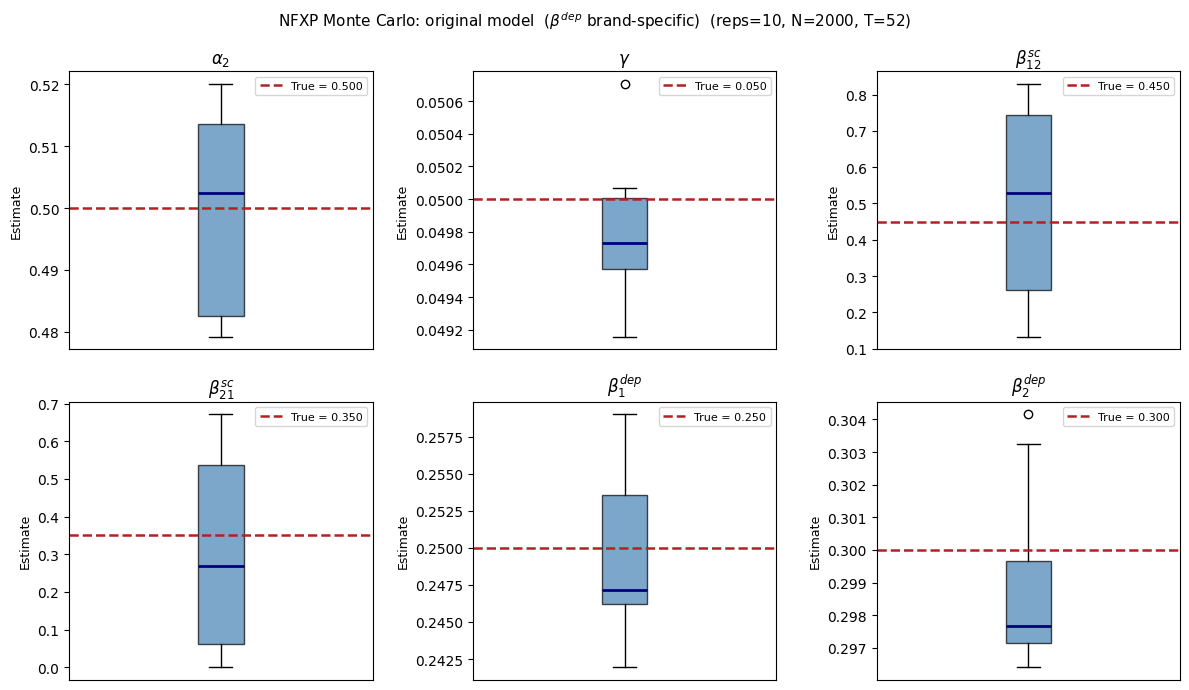

In [121]:
# LaTeX labels for each parameter (used in plots)
latex_lbl = {
    "alpha_2":    r"$\alpha_2$",
    "gamma":      r"$\gamma$",
    "beta_sc_12": r"$\beta^{sc}_{12}$",
    "beta_sc_21": r"$\beta^{sc}_{21}$",
    "beta_dep_1": r"$\beta^{dep}_1$",
    "beta_dep_2": r"$\beta^{dep}_2$",
}

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for ax, (i, name) in zip(axes, enumerate(PARAM_NAMES)):
    est    = results[results["param"] == name]["estimate"].to_numpy()
    true_v = THETA_TRUE[i]
    # Box shows distribution of MC estimates; dashed line marks true value
    ax.boxplot(est, vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.7),
               medianprops=dict(color="navy", linewidth=2))
    ax.axhline(true_v, color="firebrick", lw=1.8, ls="--",
               label=f"True = {true_v:.3f}")
    ax.set_title(latex_lbl.get(name, name), fontsize=12)
    ax.set_ylabel("Estimate", fontsize=9)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.NullLocator())

fig.suptitle(
    r"NFXP Monte Carlo: original model  ($\beta^{dep}$ brand-specific)"
    f"  (reps={MC_REPS}, N={N}, T={T})",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("nfxp_mc_boxplots_original.pdf", bbox_inches="tight")
plt.show()

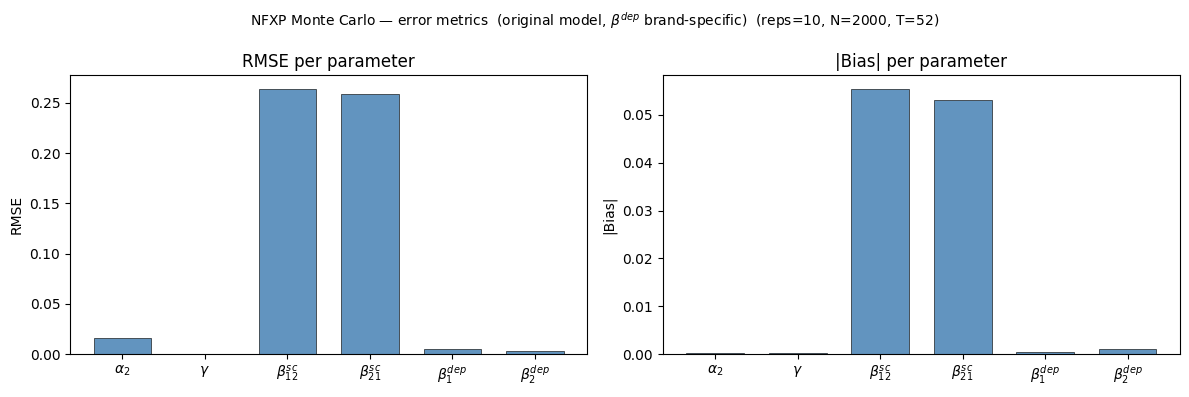

In [122]:
# Bias and RMSE bar chart — summarizes estimation accuracy across parameters
labels   = [latex_lbl.get(n, n) for n in PARAM_NAMES]
bias_abs = [abs(summary.loc[summary["param"] == n, "bias"].values[0]) for n in PARAM_NAMES]
rmse_v   = [summary.loc[summary["param"] == n, "rmse"].values[0]      for n in PARAM_NAMES]

x = np.arange(len(PARAM_NAMES))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, vals, ylabel, title in [
    (axes[0], rmse_v,   "RMSE",   "RMSE per parameter"),
    (axes[1], bias_abs, "|Bias|", "|Bias| per parameter"),
]:
    ax.bar(x, vals, 2 * w, color="steelblue", alpha=0.85, edgecolor="black", lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.axhline(0, color="black", lw=0.5)

fig.suptitle(
    r"NFXP Monte Carlo — error metrics  (original model, $\beta^{dep}$ brand-specific)"
    f"  (reps={MC_REPS}, N={N}, T={T})",
    fontsize=10,
)
plt.tight_layout()
plt.savefig("nfxp_mc_bias_rmse_original.pdf", bbox_inches="tight")
plt.show()